In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
sales = pd.read_csv("../data/raw/m5/sales_train_evaluation.csv")
calendar = pd.read_csv("../data/raw/m5/calendar.csv")
prices = pd.read_csv("../data/raw/m5/sell_prices.csv")

In [7]:
print("Sales shape:", sales.shape)
print("Calender shape:", calendar.shape)
print("Prices Shape: ", prices.shape)

Sales shape: (30490, 1947)
Calender shape: (1969, 14)
Prices Shape:  (6841121, 4)


In [8]:
sales.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1


In [9]:
print("=== SALES ===")
print(sales.isnull().sum()[sales.isnull().sum()>0])


=== SALES ===
Series([], dtype: int64)


In [10]:
print("\n=== CALENDAR ===")
print(calendar.isnull().sum()[calendar.isnull().sum()>0])


=== CALENDAR ===
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64


In [11]:
print("\n=== PRICES ===")
print(prices.isnull().sum()[prices.isnull().sum()>0])


=== PRICES ===
Series([], dtype: int64)


In [12]:
print(sales.dtypes[:10])
print(calendar.dtypes)
print(prices.dtypes)



id          object
item_id     object
dept_id     object
cat_id      object
store_id    object
state_id    object
d_1          int64
d_2          int64
d_3          int64
d_4          int64
dtype: object
date            object
wm_yr_wk         int64
weekday         object
wday             int64
month            int64
year             int64
d               object
event_name_1    object
event_type_1    object
event_name_2    object
event_type_2    object
snap_CA          int64
snap_TX          int64
snap_WI          int64
dtype: object
store_id       object
item_id        object
wm_yr_wk        int64
sell_price    float64
dtype: object


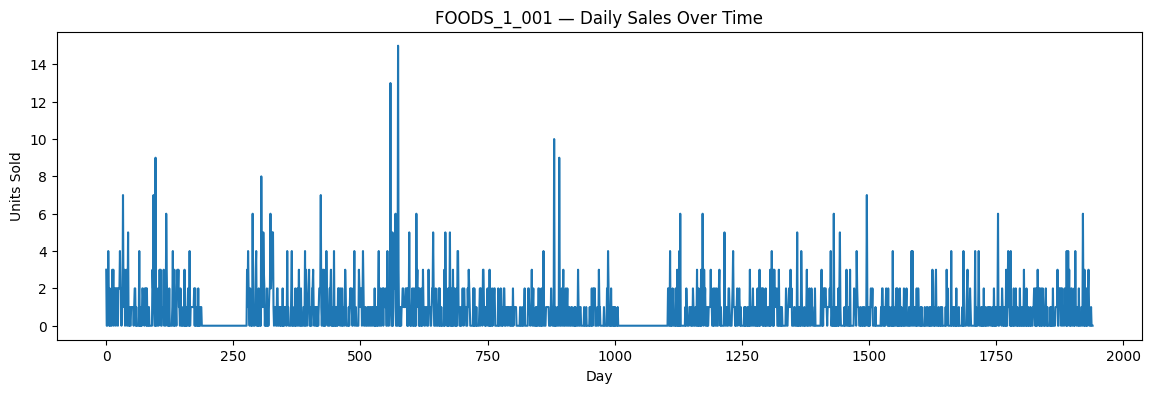

In [15]:
item = sales[sales["item_id"] == "FOODS_1_001"].iloc[0]
day_cols = [c for c in sales.columns if c.startswith("d_")]
plt.figure(figsize=(14, 4))
plt.plot(item[day_cols].values)
plt.title("FOODS_1_001 — Daily Sales Over Time")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.show()


In [16]:
print(prices["sell_price"].describe())
print("\nNegative prices:", (prices["sell_price"] < 0).sum())
print("Zero prices:", (prices["sell_price"] == 0).sum())


count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

Negative prices: 0
Zero prices: 0


In [17]:
day_cols = [c for c in sales.columns if c.startswith("d_")]
print("Number of day columns:", len(day_cols))
print("Sales value counts (sample):")
print(sales[day_cols].stack().describe())
print("\nZero sales %:", (sales[day_cols] == 0).sum().sum() / (sales.shape[0] * len(day_cols)) * 100, "%")


Number of day columns: 1941
Sales value counts (sample):
count    5.918109e+07
mean     1.130888e+00
std      3.870038e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      7.630000e+02
dtype: float64

Zero sales %: 67.99776584040612 %


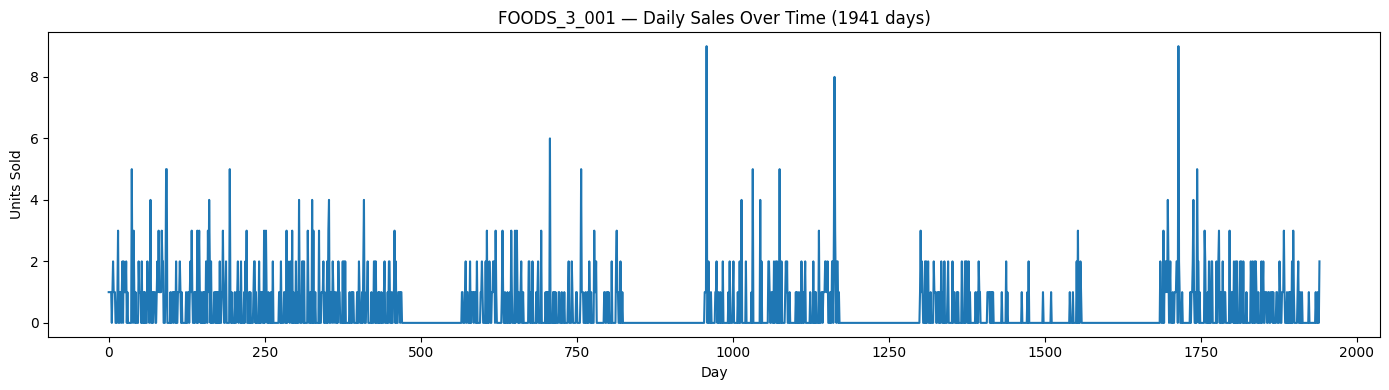

In [18]:
item = sales[sales["item_id"] == "FOODS_3_001"].iloc[0]
plt.figure(figsize=(14, 4))
plt.plot(item[day_cols].values)
plt.title("FOODS_3_001 — Daily Sales Over Time (1941 days)")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()


In [19]:
print(prices["sell_price"].describe())
print("\nNegative prices:", (prices["sell_price"] < 0).sum())
print("Zero prices:", (prices["sell_price"] == 0).sum())
print("\nUnique stores in prices:", prices["store_id"].nunique())
print("Unique items in prices:", prices["item_id"].nunique())


count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

Negative prices: 0
Zero prices: 0

Unique stores in prices: 10
Unique items in prices: 3049


In [20]:
print("Unique event types:", calendar["event_type_1"].dropna().unique())
print("\nEvent counts:\n", calendar["event_name_1"].value_counts().head(10))
print("\nSNAP days per state:")
print("CA:", calendar["snap_CA"].sum())
print("TX:", calendar["snap_TX"].sum())
print("WI:", calendar["snap_WI"].sum())


Unique event types: ['Sporting' 'Cultural' 'National' 'Religious']

Event counts:
 event_name_1
SuperBowl        6
ValentinesDay    6
PresidentsDay    6
LentStart        6
LentWeek2        6
StPatricksDay    6
Purim End        6
Pesach End       6
MemorialDay      6
Mother's day     6
Name: count, dtype: int64

SNAP days per state:
CA: 650
TX: 650
WI: 650


In [21]:
print("Categories:", sales["cat_id"].unique())
print("\nItems per category:")
print(sales["cat_id"].value_counts())
print("\nStores:", sales["store_id"].unique())
print("\nStates:", sales["state_id"].unique())


Categories: ['HOBBIES' 'HOUSEHOLD' 'FOODS']

Items per category:
cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

Stores: ['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']

States: ['CA' 'TX' 'WI']


In [22]:
print("""
M5 EDA SUMMARY
==============
- 30,490 time series (item × store combinations)
- 1,941 days of sales data (~5.3 years)
- 68% zero sales → intermittent demand, keep zeros
- date column in calendar is string → needs datetime conversion
- event nulls in calendar → fill with 'None'
- prices are clean, range $0.01 - $107.32
- Join key: store_id + item_id + wm_yr_wk

CLEANING PLAN:
- Melt sales wide → long format
- Convert calendar.date to datetime
- Fill calendar event nulls with 'None'
- Join sales + calendar + prices
- Add revenue = unit_sales × sell_price
""")



M5 EDA SUMMARY
- 30,490 time series (item × store combinations)
- 1,941 days of sales data (~5.3 years)
- 68% zero sales → intermittent demand, keep zeros
- date column in calendar is string → needs datetime conversion
- event nulls in calendar → fill with 'None'
- prices are clean, range $0.01 - $107.32
- Join key: store_id + item_id + wm_yr_wk

CLEANING PLAN:
- Melt sales wide → long format
- Convert calendar.date to datetime
- Fill calendar event nulls with 'None'
- Join sales + calendar + prices
- Add revenue = unit_sales × sell_price

